In [1]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt

In [11]:
# Traning set
import os
base_dir = "Dataset"
for a , b ,c in os.walk(base_dir):
    print(f"For {a} we have {len(b)} sub-folder having has {len(c)} images.")

For Dataset we have 1 sub-folder having has 0 images.
For Dataset\train we have 5 sub-folder having has 0 images.
For Dataset\train\Cancer we have 0 sub-folder having has 125 images.
For Dataset\train\Cassiopeia we have 0 sub-folder having has 118 images.
For Dataset\train\Centaurus we have 0 sub-folder having has 129 images.
For Dataset\train\Leo we have 0 sub-folder having has 298 images.
For Dataset\train\Orian we have 0 sub-folder having has 306 images.


In [21]:
# making test images 
import shutil
import random

Target_foler_name = os.listdir(base_dir+ "/train")

train_path = os.path.join(base_dir , "train")
test_path = os.path.join(base_dir , "test")

for folder_name in Target_foler_name:
    
    train_subfolder = os.path.join(train_path , folder_name)
    test_subfolder = os.path.join(test_path , folder_name)
    
    os.makedirs(test_subfolder , exist_ok= False)
    
    images = [f for f in os.listdir(train_subfolder) if os.path.isfile(os.path.join(train_subfolder , f))]
    
    # Select randomly 20%
    num_of_img_tranfer = max(1 , int(len(images)*0.2))
    img_2_tranfer = random.sample(images , k = num_of_img_tranfer)
    
    # Tranfer file from train to test
    for img in img_2_tranfer:
        src = os.path.join(train_subfolder , img)
        des = os.path.join(test_subfolder , img)
        shutil.move(src , des)
        
    print(f"Created and populated {folder_name} in test folder.")

Created and populated Cancer in test folder.
Created and populated Cassiopeia in test folder.
Created and populated Centaurus in test folder.
Created and populated Leo in test folder.
Created and populated Orian in test folder.


In [22]:
# Now the dataset status
# Traning set
import os
base_dir = "Dataset"
for a , b ,c in os.walk(base_dir):
    print(f"For {a} we have {len(b)} sub-folder having has {len(c)} images.")

For Dataset we have 2 sub-folder having has 0 images.
For Dataset\test we have 5 sub-folder having has 0 images.
For Dataset\test\Cancer we have 0 sub-folder having has 20 images.
For Dataset\test\Cassiopeia we have 0 sub-folder having has 23 images.
For Dataset\test\Centaurus we have 0 sub-folder having has 25 images.
For Dataset\test\Leo we have 0 sub-folder having has 59 images.
For Dataset\test\Orian we have 0 sub-folder having has 61 images.
For Dataset\train we have 5 sub-folder having has 0 images.
For Dataset\train\Cancer we have 0 sub-folder having has 80 images.
For Dataset\train\Cassiopeia we have 0 sub-folder having has 95 images.
For Dataset\train\Centaurus we have 0 sub-folder having has 104 images.
For Dataset\train\Leo we have 0 sub-folder having has 239 images.
For Dataset\train\Orian we have 0 sub-folder having has 245 images.


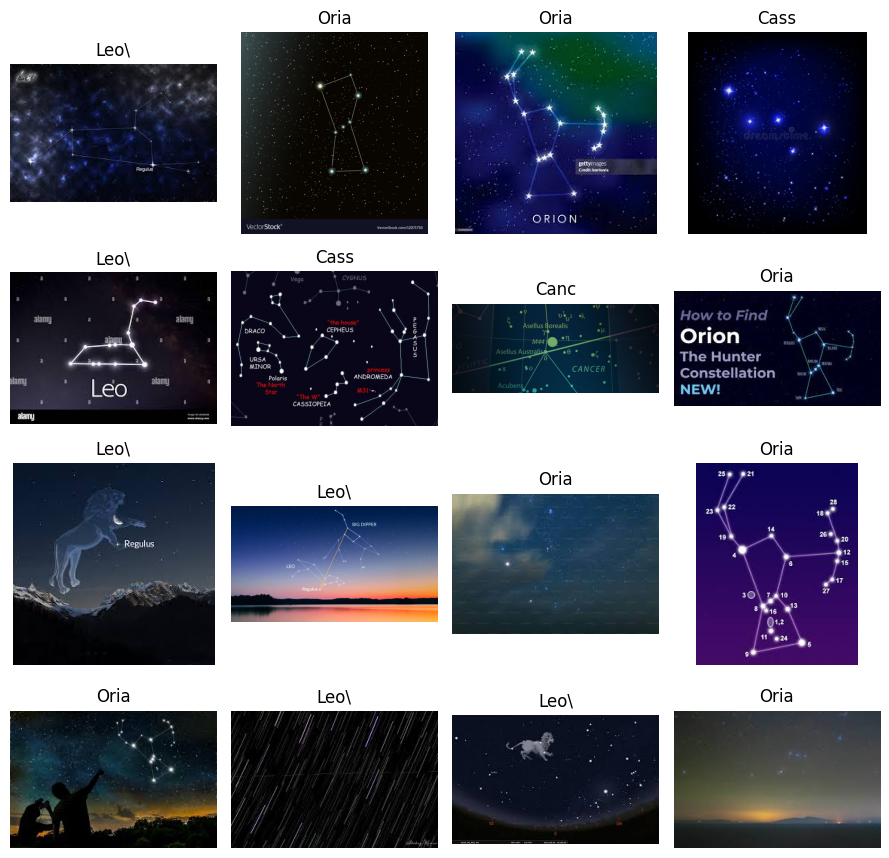

In [50]:
# Visualise some data 
from glob import glob
from PIL import Image

train_dir = "Dataset/train"
test_dir = "Dataset/test"

fig = plt.figure(figsize=(9 , 9))
row , col = 4 , 4
img_list = glob(train_dir + "/*/*.jpg")

for i in range(row*col):
    
    random_img = random.sample(img_list , k = 1)
    
    img = Image.open(random_img[0])
    plt.subplot(row , col , i+1)
    plt.imshow(img)
    plt.title(random_img[0].split('/')[1][6:10])
    plt.axis("off")
    plt.tight_layout()

In [25]:
# Transforming the data
from torch.utils.data import DataLoader 
from torchvision import transforms

data_tranform = transforms.Compose([
    transforms.Resize((224 , 224) , interpolation=transforms.InterpolationMode.NEAREST),
    transforms.TrivialAugmentWide(num_magnitude_bins= 3),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.485, 0.456, 0.406] , std=[0.229,
                            0.224, 0.225])
])

In [51]:
# Importing the data
from torchvision import datasets

train_data = datasets.ImageFolder(train_dir , 
                                  transform= data_tranform ,
                                  target_transform= None)
test_data = datasets.ImageFolder(test_dir , 
                                  transform= data_tranform ,
                                  target_transform= None)

In [58]:
train_data.class_to_idx, test_data.class_to_idx

({'Cancer': 0, 'Cassiopeia': 1, 'Centaurus': 2, 'Leo': 3, 'Orian': 4},
 {'Cancer': 0, 'Cassiopeia': 1, 'Centaurus': 2, 'Leo': 3, 'Orian': 4})

In [60]:
# Hyperparamter
 
BATCH_SIZE = 16
LR = 0.01


In [15]:
len(train) # how many batches are there in the train ( each batch has 32 images)

27

In [16]:
len(test)

1

In [17]:
len(val)

1